# Inciso 6.3- 6.6

### Librerías importadas.

In [2]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [64]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import math
from sklearn.metrics import f1_score, classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone
import seaborn as sns

### Importación de datos.

In [4]:
df = pd.read_csv('datos_predictores_bloques.csv')
df.head(2)

,lago,fecha,bloque_fila,bloque_columna,x,y,b03,b04,b05,b08,ndci,ndvi,ndwi,proporcion_agua,proporcion_tierra,proporcion_otro,chl_a_estimada,pixeles_validos,alta_cianobacteria,id_bloque
0,amatitlan,2025-01-28,1594,754,754500.0,1594500.0,0.132696,0.138698,0.144296,0.184101,0.032449,0.145970,-0.164748,0.009569,0.251196,0.739234,4.664739,418,0,amatitlan_1594_754
1,amatitlan,2025-01-28,1594,755,755500.0,1594500.0,0.088559,0.080894,0.100493,0.206473,0.147543,0.441826,-0.395174,0.003158,0.763158,0.233684,8.154140,950,0,amatitlan_1594_755


### Valores faltantes.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7194 entries, 0 to 7193
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   lago                7194 non-null   object 
 1   fecha               7194 non-null   object 
 2   bloque_fila         7194 non-null   int64  
 3   bloque_columna      7194 non-null   int64  
 4   x                   7194 non-null   float64
 5   y                   7194 non-null   float64
 6   b03                 7194 non-null   float64
 7   b04                 7194 non-null   float64
 8   b05                 7194 non-null   float64
 9   b08                 7194 non-null   float64
 10  ndci                7194 non-null   float64
 11  ndvi                7194 non-null   float64
 12  ndwi                7194 non-null   float64
 13  proporcion_agua     7194 non-null   float64
 14  proporcion_tierra   7194 non-null   float64
 15  proporcion_otro     7194 non-null   float64
 16  chl_a_

No hay valores faltantes.

### Muestra de datos

In [6]:
proporcion = 0.01
df, _ = train_test_split(df, train_size=proporcion, stratify=df["alta_cianobacteria"], random_state=0)
df = df.reset_index(drop=True)

In [7]:
df.shape

(71, 20)

### Etiquetas y variable objetivo.

In [8]:
columnas_excluir = [
    "lago",
    "fecha",
    "alta_cianobacteria",
    "ndci",
    "chl_a_estimada",
    "b04",
    "b05",
    "id_bloque",
    "celda_fila",
    "celda_columna"
]

X = df.drop(
    columns=columnas_excluir,
    errors="ignore"
)

y = df["alta_cianobacteria"].astype(int)

### Conjunto de entrenamiento y prueba (para la validación aleatoria)

In [9]:
X_train_aleatorio, X_test_aleatorio, y_train_aleatorio, y_test_aleatorio = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

### Conjunto de entrenamiento (para validación espacial)

In [10]:
groups = df["id_bloque"]
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

idx_train_esp, idx_test_esp = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train_esp = X.iloc[idx_train_esp].copy()
X_test_esp = X.iloc[idx_test_esp].copy()

y_train_esp = y.iloc[idx_train_esp].copy()
y_test_esp = y.iloc[idx_test_esp].copy()

groups_train_esp = groups.iloc[idx_train_esp].copy()
groups_test_esp = groups.iloc[idx_test_esp].copy()

In [11]:
#Comprobación de que se ha separado correctamente
assert set(groups_train_esp).isdisjoint(
    set(groups_test_esp)
)

print(
    "Bloques train:",
    groups_train_esp.nunique()
)

print(
    "Bloques test:",
    groups_test_esp.nunique()
)

print(
    "Bloques compartidos:",
    len(
        set(groups_train_esp)
        &
        set(groups_test_esp)
    )
)

Bloques train: 46
Bloques test: 20
Bloques compartidos: 0


## Regresión logística.

### Preprocesamiento a utilizar.

In [12]:
pipeline_rl = Pipeline(steps=[("minmax_scaler", MinMaxScaler()),
                                   ("modelo", LogisticRegression(max_iter=1000, random_state=0))])

### Rejilla de hiperparámetros.

In [13]:
#rejilla_rl = [
#    {
#        "modelo__solver": ["liblinear"],
#        "modelo__penalty": ["l1", "l2"],
#        "modelo__C": [0.01, 0.1, 1, 10]
#    },
#    {
#        "modelo__solver": ["lbfgs"],
#        "modelo__penalty": ["l2"],
#        "modelo__C": [0.01, 0.1, 1, 10]
#    }
#]

rejilla_rl = [{'modelo__C': [10], 'modelo__penalty': ['l2'], 'modelo__solver': ['liblinear']}]

### GridSearch -aleatorio-.

In [14]:
grid_search_rl = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=rejilla_rl,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

### GridSearch -espacial-

In [15]:
from sklearn.model_selection import StratifiedGroupKFold

cv_espacial = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
#GRIDSEARCH REGRESIÓN LOGÍSTICA
grid_rl_esp = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=rejilla_rl,
    scoring="f1",
    cv=cv_espacial,
    n_jobs=-1,
    return_train_score=True
)


### Entrenamiento del modelo.

In [16]:
grid_search_rl.fit(X_train_aleatorio, y_train_aleatorio)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"[{'modelo__C': [10], 'modelo__penalty': ['l2'], 'modelo__solver': ['liblinear']}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


In [17]:
grid_rl_esp.fit(X_train_esp,y_train_esp,groups=groups_train_esp) #ESPACIAL

,estimator,Pipeline(step...om_state=0))])
,param_grid,"[{'modelo__C': [10], 'modelo__penalty': ['l2'], 'modelo__solver': ['liblinear']}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


### Mejor modelo e hiperparámetros.

In [18]:
print("Mejores hiperparámetros:", grid_search_rl.best_params_)
print("Mejor accuracy promedio en validación:", grid_search_rl.best_score_)

mejor_lr = grid_search_rl.best_estimator_

Mejores hiperparámetros: {'modelo__C': 10, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
Mejor accuracy promedio en validación: 0.811010101010101


## Random Forest.

### Preprocesamiento a utilizar.

In [19]:
pipeline_rf = Pipeline(steps=[("preprocesamiento", MinMaxScaler(feature_range=(0, 1))),
                              ("modelo", RandomForestClassifier(random_state=42))])

### Rejilla de hiperparámetros.

In [20]:
#rejilla_rf = {
#    "modelo__n_estimators": [50, 100, 200],
#    "modelo__max_depth": [3, 5, 7],
#    "modelo__min_samples_split": [2, 5, 8],
#    "modelo__min_samples_leaf": [1, 2, 4],
#    "modelo__max_features": ["sqrt", "log2"]
#}
rejilla_rf = {
    "modelo__n_estimators": [200],
    "modelo__max_depth": [7],
    "modelo__min_samples_split": [5],
    "modelo__min_samples_leaf": [1],
    "modelo__max_features": ["sqrt"]
}


### GridSearch -Aleatorio-

In [21]:
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=rejilla_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

### GridSearch -Espacial-

In [22]:
grid_rf_esp = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=rejilla_rf,
    scoring="f1",
    cv=cv_espacial,
    n_jobs=-1,
    return_train_score=True
)

### Entrenamiento del modelo.

In [23]:
grid_search_rf.fit(X_train_aleatorio, y_train_aleatorio)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__max_depth': [7], 'modelo__max_features': ['sqrt'], 'modelo__min_samples_leaf': [1], 'modelo__min_samples_split': [5], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


In [24]:
grid_rf_esp.fit(X_train_esp,y_train_esp,groups=groups_train_esp)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__max_depth': [7], 'modelo__max_features': ['sqrt'], 'modelo__min_samples_leaf': [1], 'modelo__min_samples_split': [5], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


### Mejor modelo e hiperparámetros.

In [25]:
print("Mejores hiperparámetros:", grid_search_rf.best_params_)
print("Mejor accuracy en validación:", grid_search_rf.best_score_)
mejor_rf = grid_search_rf.best_estimator_

Mejores hiperparámetros: {'modelo__max_depth': 7, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}
Mejor accuracy en validación: 0.8533333333333333


## XGBoost

### Preprocesamiento a utilizar.

In [26]:
pipeline_xgb = Pipeline(steps=[
    ("preprocesamiento", MinMaxScaler(feature_range=(0, 1))),
    ("modelo", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=0,
        n_jobs=1
    ))
])

### Rejilla de hiperparámetros.

In [27]:
#rejilla_xgb = {
#    "modelo__n_estimators": [100, 200, 300],
#    "modelo__max_depth": [3, 5, 7],
#    "modelo__learning_rate": [0.01, 0.1, 0.2],
#    "modelo__subsample": [0.8, 1.0],
#    "modelo__colsample_bytree": [0.8, 1.0]
#}
rejilla_xgb = {
    "modelo__n_estimators": [300],
    "modelo__max_depth": [5],
    "modelo__learning_rate": [0.1],
    "modelo__subsample": [1.0],
    "modelo__colsample_bytree": [1.0]
}

### GridSearch -aleatorio-

In [28]:
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=rejilla_xgb,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

### GridSearch -espacial-

In [29]:
grid_xgb_esp = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=rejilla_xgb,
    scoring="f1",
    cv=cv_espacial,
    n_jobs=-1,
    return_train_score=True
)

### Entrenamiento del modelo.

In [30]:
grid_search_xgb.fit(X_train_aleatorio, y_train_aleatorio)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'modelo__colsample_bytree': [1.0], 'modelo__learning_rate': [0.1], 'modelo__max_depth': [5], 'modelo__n_estimators': [300], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


In [31]:
grid_xgb_esp.fit(X_train_esp,y_train_esp,groups=groups_train_esp) #espacial

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'modelo__colsample_bytree': [1.0], 'modelo__learning_rate': [0.1], 'modelo__max_depth': [5], 'modelo__n_estimators': [300], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


### Mejor modelo e hiperparámetros.

In [32]:
mejor_xgb = grid_search_xgb.best_estimator_
print("Mejor accuracy en validación:", grid_search_xgb.best_score_)
print("Mejores hiperparámetros:", grid_search_xgb.best_params_)

Mejor accuracy en validación: 0.821010101010101
Mejores hiperparámetros: {'modelo__colsample_bytree': 1.0, 'modelo__learning_rate': 0.1, 'modelo__max_depth': 5, 'modelo__n_estimators': 300, 'modelo__subsample': 1.0}


### Evaluación de modelos espaciales

In [33]:
mejor_rl_esp = grid_rl_esp.best_estimator_
mejor_rf_esp = grid_rf_esp.best_estimator_
mejor_xgb_esp = grid_xgb_esp.best_estimator_

### Predicciones modelos espaciales

In [34]:
pred_rl_esp = mejor_rl_esp.predict(X_test_esp)

pred_rf_esp = mejor_rf_esp.predict(X_test_esp)

pred_xgb_esp = mejor_xgb_esp.predict(X_test_esp)

### Probabilidades de modelos espaciales

In [35]:
prob_rl_esp = mejor_rl_esp.predict_proba(X_test_esp)[:, 1]

prob_rf_esp = mejor_rf_esp.predict_proba(X_test_esp)[:, 1]

prob_xgb_esp = mejor_xgb_esp.predict_proba(X_test_esp)[:, 1]

### Con respecto a las versiones originales (aleatorias)

In [36]:
#MEJOR MODELO
mejor_rl_aleatorio = grid_search_rl.best_estimator_
mejor_rf_aleatorio = grid_search_rf.best_estimator_
mejor_xgb_aleatorio = grid_search_xgb.best_estimator_

#PROBABILIDADES
pred_rl_aleatorio = mejor_rl_aleatorio.predict(X_test_aleatorio)
prob_rl_aleatorio = mejor_rl_aleatorio.predict_proba(X_test_aleatorio)[:, 1]

pred_rf_aleatorio = mejor_rf_aleatorio.predict(X_test_aleatorio)
prob_rf_aleatorio = mejor_rf_aleatorio.predict_proba(X_test_aleatorio)[:, 1]

pred_xgb_aleatorio = mejor_xgb_aleatorio.predict(X_test_aleatorio)
prob_xgb_aleatorio = mejor_xgb_aleatorio.predict_proba(X_test_aleatorio)[:, 1]


## Resultados

### Métricas

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)


def evaluar_modelo(y_true, y_pred, y_prob):

    return {
        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                y_prob
            )
    }

### Espaciales

In [38]:
resultados_esp = {
    "Regresión Logística":
        evaluar_modelo(
            y_test_esp,
            pred_rl_esp,
            prob_rl_esp
        ),

    "Random Forest":
        evaluar_modelo(
            y_test_esp,
            pred_rf_esp,
            prob_rf_esp
        ),

    "XGBoost":
        evaluar_modelo(
            y_test_esp,
            pred_xgb_esp,
            prob_xgb_esp
        )
}

df_esp = (
    pd.DataFrame(resultados_esp)
    .T
)

display(df_esp)

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Regresión Logística,0.809524,0.813636,0.750000,0.9,0.818182,0.909091
Random Forest,0.857143,0.863636,0.769231,1.0,0.869565,0.909091
XGBoost,0.857143,0.863636,0.769231,1.0,0.869565,0.900000


### Aleatorios

In [39]:
resultados_aleatorios = {
    "Regresión Logística":
        evaluar_modelo(
            y_test_aleatorio,
            pred_rl_aleatorio,
            prob_rl_aleatorio
        ),

    "Random Forest":
        evaluar_modelo(
            y_test_aleatorio,
            pred_rf_aleatorio,
            prob_rf_aleatorio
        ),

    "XGBoost":
        evaluar_modelo(
            y_test_aleatorio,
            pred_xgb_aleatorio,
            prob_xgb_aleatorio
        )
}

df_aleatorio = (
    pd.DataFrame(resultados_aleatorios)
    .T
)

display(df_aleatorio)

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Regresión Logística,0.909091,0.916667,0.833333,1.0,0.909091,0.950000
Random Forest,0.909091,0.916667,0.833333,1.0,0.909091,0.983333
XGBoost,0.954545,0.958333,0.909091,1.0,0.952381,0.950000


### Comparación entre la versión original (aleatoria) y la espacial

In [40]:
comparacion = pd.concat(
    {
        "Aleatoria": df_aleatorio,
        "Espacial": df_esp
    },
    names=[
        "Validación",
        "Modelo"
    ]
)

display(
    comparacion.round(3)
)

Accuracy  Balanced Accuracy  Precision  \
Validación Modelo                                                        
Aleatoria  Regresión Logística     0.909              0.917      0.833   
           Random Forest           0.909              0.917      0.833   
           XGBoost                 0.955              0.958      0.909   
Espacial   Regresión Logística     0.810              0.814      0.750   
           Random Forest           0.857              0.864      0.769   
           XGBoost                 0.857              0.864      0.769   

                                Recall     F1  ROC-AUC  
Validación Modelo                                       
Aleatoria  Regresión Logística     1.0  0.909    0.950  
           Random Forest           1.0  0.909    0.983  
           XGBoost                 1.0  0.952    0.950  
Espacial   Regresión Logística     0.9  0.818    0.909  
           Random Forest           1.0  0.870    0.909  
           XGBoost                 1.0  0.870    0.900

### Diferencia de las métricas

In [41]:
diferencias = (df_esp -df_aleatorio)
display(diferencias.round(3))

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Regresión Logística,-0.100,-0.103,-0.083,-0.1,-0.091,-0.041
Random Forest,-0.052,-0.053,-0.064,0.0,-0.040,-0.074
XGBoost,-0.097,-0.095,-0.140,0.0,-0.083,-0.050


# Inciso 7

In [54]:
#Algunas funciones para este inciso
def evaluar_modelo(y_true, y_pred, y_prob):

    return {
        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                y_prob
            )
    }

## Experimento A: Atitlán $\rightarrow$ Amatitlán

Se establece como conjunto de entrenamiento los datos del lago de Atitlán y como prueba los datos del lago de Amatitlán

In [43]:
mask_train_A = (
    df["lago"] == "atitlan"
)

mask_test_A = (
    df["lago"] == "amatitlan"
)

In [44]:
X_train_A = X.loc[mask_train_A].copy()
y_train_A = y.loc[mask_train_A].copy()

X_test_A = X.loc[mask_test_A].copy()
y_test_A = y.loc[mask_test_A].copy()

In [45]:
print("EXPERIMENTO A")

print("Train:", X_train_A.shape)
print("Test :", X_test_A.shape)

print("\nDistribución train:")
print(y_train_A.value_counts(normalize=True))

print("\nDistribución test:")
print(y_test_A.value_counts(normalize=True))

EXPERIMENTO A
Train: (52, 12)
Test : (19, 12)

Distribución train:
alta_cianobacteria
1    0.519231
0    0.480769
Name: proportion, dtype: float64

Distribución test:
alta_cianobacteria
0    0.684211
1    0.315789
Name: proportion, dtype: float64


In [50]:
#Entrenamiento para el experimento A
#Se hace uso de los pipelines para este fin
modelo_rl_A = clone(pipeline_rl)
modelo_rf_A = clone(pipeline_rf)
modelo_xgb_A = clone(pipeline_xgb)

modelo_rl_A.fit(X_train_A,y_train_A)

modelo_rf_A.fit(X_train_A,y_train_A)

modelo_xgb_A.fit(X_train_A,y_train_A)

,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


In [55]:
#Evaluación del experimento A
#REGRESON LOGISTICA
pred_A_rl = modelo_rl_A.predict(X_test_A)
prob_A_rl = modelo_rl_A.predict_proba(X_test_A)[:, 1]
metricas_A_rl = evaluar_modelo(y_test_A,pred_A_rl,prob_A_rl)

#RANDOM FOREST
pred_A_rf = modelo_rf_A.predict(X_test_A)
prob_A_rf = modelo_rf_A.predict_proba(X_test_A)[:, 1]
metricas_A_rf = evaluar_modelo(y_test_A,pred_A_rf,prob_A_rf)


#XGBOOST
pred_A_xgb = modelo_xgb_A.predict(X_test_A)
prob_A_xgb = modelo_xgb_A.predict_proba(X_test_A)[:, 1]
metricas_A_xgb = evaluar_modelo(y_test_A,pred_A_xgb,prob_A_xgb)


In [56]:
resultados_A = pd.DataFrame({
    "Regresión Logística":
        metricas_A_rl,

    "Random Forest":
        metricas_A_rf,

    "XGBoost":
        metricas_A_xgb
}).T

## Experimento B: Amatitlán $\rightarrow$ Atitlán

Se establece como conjunto de entrenamiento los datos del lago de Amatitlán y como conjunto de prueba los datos del lago de Atitlán.

In [47]:
mask_train_B = (
    df["lago"] == "amatitlan"
)

mask_test_B = (
    df["lago"] == "atitlan"
)

X_train_B = X.loc[mask_train_B].copy()
y_train_B = y.loc[mask_train_B].copy()

X_test_B = X.loc[mask_test_B].copy()
y_test_B = y.loc[mask_test_B].copy()

In [51]:
#Entrenamiento para el experimento B
#Se hace nuevamente uso de los pipelines para este fin
modelo_rl_B = clone(pipeline_rl)
modelo_rf_B = clone(pipeline_rf)
modelo_xgb_B = clone(pipeline_xgb)

modelo_rl_B.fit(X_train_B, y_train_B)
modelo_rf_B.fit(X_train_B, y_train_B)
modelo_xgb_B.fit(X_train_B, y_train_B)

,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


In [57]:
#Evaluación del experimento B
#REGRESON LOGISTICA
pred_B_rl = modelo_rl_B.predict(X_test_B)
prob_B_rl = modelo_rl_B.predict_proba(X_test_B)[:, 1]
metricas_B_rl = evaluar_modelo(y_test_B,pred_B_rl,prob_B_rl)

#RANDOM FOREST
pred_B_rf = modelo_rf_B.predict(X_test_B)
prob_B_rf = modelo_rf_B.predict_proba(X_test_B)[:, 1]
metricas_B_rf = evaluar_modelo(y_test_B,pred_B_rf,prob_B_rf)


#XGBOOST
pred_B_xgb = modelo_xgb_B.predict(X_test_B)
prob_B_xgb = modelo_xgb_B.predict_proba(X_test_B)[:, 1]
metricas_B_xgb = evaluar_modelo(y_test_B,pred_B_xgb,prob_B_xgb)

In [58]:
resultados_B = pd.DataFrame({
    "Regresión Logística":
        metricas_B_rl,

    "Random Forest":
        metricas_B_rf,

    "XGBoost":
        metricas_B_xgb
}).T

### 7.3. Métricas de evaluación para ambos experimentos

In [59]:
comparacion_lagos = pd.concat(
    {
        "Atitlán → Amatitlán":
            resultados_A,

        "Amatitlán → Atitlán":
            resultados_B
    },
    names=[
        "Experimento",
        "Modelo"
    ]
)

display(
    comparacion_lagos.round(3)
)

Accuracy  Balanced Accuracy  \
Experimento         Modelo                                             
Atitlán → Amatitlán Regresión Logística     0.684              0.500   
                    Random Forest           1.000              1.000   
                    XGBoost                 0.947              0.917   
Amatitlán → Atitlán Regresión Logística     0.481              0.500   
                    Random Forest           0.808              0.804   
                    XGBoost                 0.846              0.849   

                                         Precision  Recall     F1  ROC-AUC  
Experimento         Modelo                                                  
Atitlán → Amatitlán Regresión Logística      0.000   0.000  0.000    1.000  
                    Random Forest            1.000   1.000  1.000    1.000  
                    XGBoost                  1.000   0.833  0.909    1.000  
Amatitlán → Atitlán Regresión Logística      0.000   0.000  0.000    0.807  
                    Random Forest            0.774   0.889  0.828    0.907  
                    XGBoost                  0.913   0.778  0.840    0.849

### 7.4. Comparación con resultados del inciso 6

In [61]:
comparacion.round(3)

Accuracy  Balanced Accuracy  Precision  \
Validación Modelo                                                        
Aleatoria  Regresión Logística     0.909              0.917      0.833   
           Random Forest           0.909              0.917      0.833   
           XGBoost                 0.955              0.958      0.909   
Espacial   Regresión Logística     0.810              0.814      0.750   
           Random Forest           0.857              0.864      0.769   
           XGBoost                 0.857              0.864      0.769   

                                Recall     F1  ROC-AUC  
Validación Modelo                                       
Aleatoria  Regresión Logística     1.0  0.909    0.950  
           Random Forest           1.0  0.909    0.983  
           XGBoost                 1.0  0.952    0.950  
Espacial   Regresión Logística     0.9  0.818    0.909  
           Random Forest           1.0  0.870    0.909  
           XGBoost                 1.0  0.870    0.900

Se tiene que la primera tabla son las métricas de los experimentos con el entrenamiento de un lago y la prueba de otro lago; la segunda tabla corresponde a aquella donde se usa el mismo lago para el entrenamiento y la prueba. Se observa que esta última tiene valores de métricas más altos que el correspondiente con los experimentos (en general, dado que en ROC-AUC si son los valores mayores en la primera tabla). Esto puede ser por la diferencia de datos entre un lago y el otro, que como se vió en laboratorios anteriores no era una diferencia pequeña. 

### 7.5. ¿Un modelo entrenado en un lago puede generalizar adecuadamente al otro?

Puede observarse que el modelo de XGBoost parece generalizar adecuadamente al observar F1. Random Forest también presenta poca variabilidad entre las métricas, por lo que también generaliza adecuadamente. El modelo de Regresión Logística no es bueno generalizando de acuerdo a las mismas métricas. Aunque según puede observarse, este funciona mejor cuando es solo un lago el que se está estudiando tanto para la verisón aleatoria como la espacial.

### 7.6. características geográficas, ambientales o espectrales que podrían explicar las diferencias encontradas.

Se llevan a cabo análisis previos para la respuesta "b08", "ndvi", "ndwi"

In [70]:
print("ESTADISTICAS B03")
df.groupby("lago")["b03"].describe()

ESTADISTICAS B03


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,19.0,0.099968,0.035192,0.058539,0.069568,0.096291,0.122055,0.167298
atitlan,52.0,0.082375,0.030251,0.045342,0.062695,0.076394,0.096983,0.198260


In [71]:
print("ESTADISTICAS B08")
df.groupby("lago")["b08"].describe()

ESTADISTICAS B08


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,19.0,0.205185,0.060723,0.043686,0.17858,0.231326,0.242206,0.271664
atitlan,52.0,0.220310,0.105927,0.013691,0.19829,0.266373,0.290469,0.376184


In [72]:
print("ESTADISTICAS NDVI")
df.groupby("lago")["ndvi"].describe()

ESTADISTICAS NDVI


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,19.0,0.364075,0.220581,-0.106987,0.212391,0.312525,0.570974,0.669277
atitlan,52.0,0.422807,0.341764,-0.275134,0.400474,0.516029,0.669547,0.801499


In [73]:
print("ESTADISTICAS NDWI")
df.groupby("lago")["ndwi"].describe()

ESTADISTICAS NDWI


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,19.0,-0.289032,0.234357,-0.556842,-0.491675,-0.323317,-0.209653,0.336916
atitlan,52.0,-0.304180,0.400556,-0.662703,-0.549320,-0.465539,-0.378808,0.553192


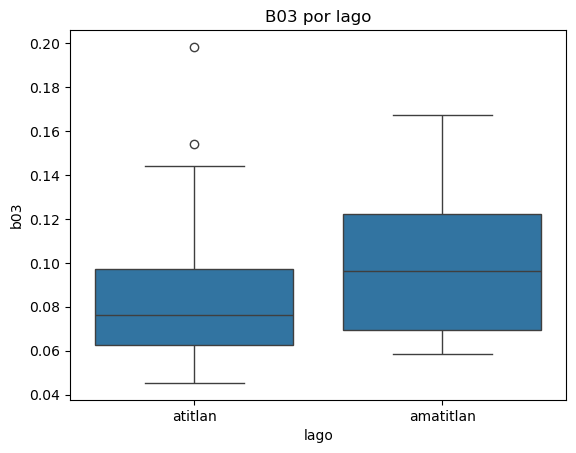

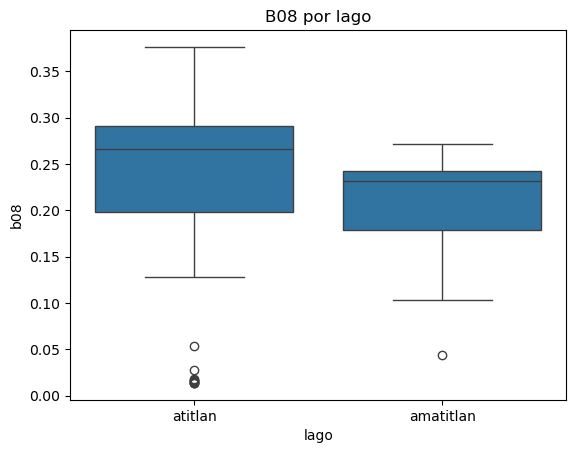

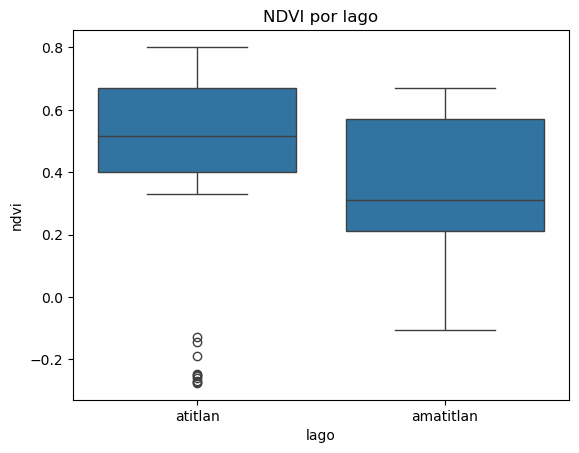

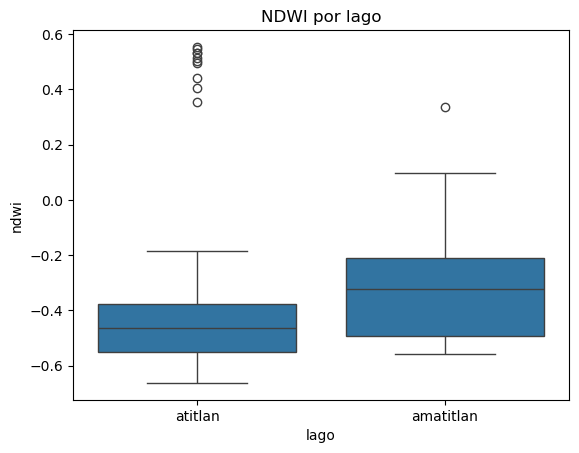

In [66]:
for variable in ["b03","b08","ndvi","ndwi"]:

    sns.boxplot(
        data=df,
        x="lago",
        y=variable
    )

    plt.title(
        f"{variable.upper()} por lago"
    )

    plt.show()

Se observa que los promedios no difieren en gran medida uno del otro, siendo los del lago de amatitlán ligeramente mayores a excepción de B03. En cuanto a la desviación estándar, la que presenta mayor diferencia respecto a la otra es la de NDWI que difieren aproximadamente por 0.2 (las demás difieren por 0.1). Es así como se puede asegurar que las variables parecen ser igual de significativas para ambos casos.